## 0. Carga del conjunto de datos

El archivo `datos_8414.npz` contiene las señales personalizadas para esta evaluación. A partir de este archivo se cargan tres arreglos principales:

- $X$: matriz de señales, donde cada fila corresponde a una señal temporal.
- $y$: etiquetas de régimen de dispersión.
- $t$: vector temporal común a todas las señales.

En particular,

$$
X \in \mathbb{R}^{24 \times 256},
$$

lo cual significa que el conjunto contiene $24$ señales, cada una muestreada en $256$ instantes de tiempo. Las etiquetas

$$
y \in \{0,1,2\}
$$

indican el régimen físico asociado a cada señal:

- $y=0$: régimen sin dispersión.
- $y=1$: régimen de dispersión intermedia.
- $y=2$: régimen de dispersión fuerte.

In [2]:
# ============================================================
# Imports
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

In [3]:
# ============================================================
# Carga del conjunto de datos
# ============================================================

datos = np.load("datos_8414.npz")

X = datos["X"]
y = datos["y"]
t = datos["t"]

## Configuración de estilo

In [4]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,

    "axes.labelsize": 16,
    "axes.titlesize": 18,

    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    "grid.color": "gray",
    "grid.linewidth": 0.3,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",

    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

##  Exploración inicial del conjunto de datos

Antes de construir el modelo de reconstrucción, es necesario inspeccionar la estructura del conjunto de datos. En esta sección se verifican las dimensiones de las variables principales y se visualiza una señal representativa de cada régimen de dispersión.

Esta exploración inicial permite confirmar que las señales están organizadas correctamente y ofrece una primera comparación cualitativa entre los tres regímenes físicos presentes en los datos:

$$
y \in \{0,1,2\}.
$$

En particular, se busca observar cómo cambia la estructura temporal de las señales $x(t)$ antes de introducir la capa Fourier y entrenar la red neuronal.

In [5]:
# ============================================================
# Exploración inicial
# ============================================================

print("X:", X.shape) # 24 señales , 8 por regimen r0 sin disp, r1 disp interm, r2 disp alta.
print("y:", y.shape)
print("t:", t.shape)

print("Regímenes:", np.unique(y, return_counts=True))

X: (24, 256)
y: (24,)
t: (256,)
Regímenes: (array([0, 1, 2]), array([8, 8, 8]))


La matriz $X$ tiene dimensión $24\times256$, por lo que cada fila representa una señal temporal $x(t)$ discretizada en $256$ puntos. La distribución de etiquetas confirma que hay $8$ señales por cada régimen de dispersión.

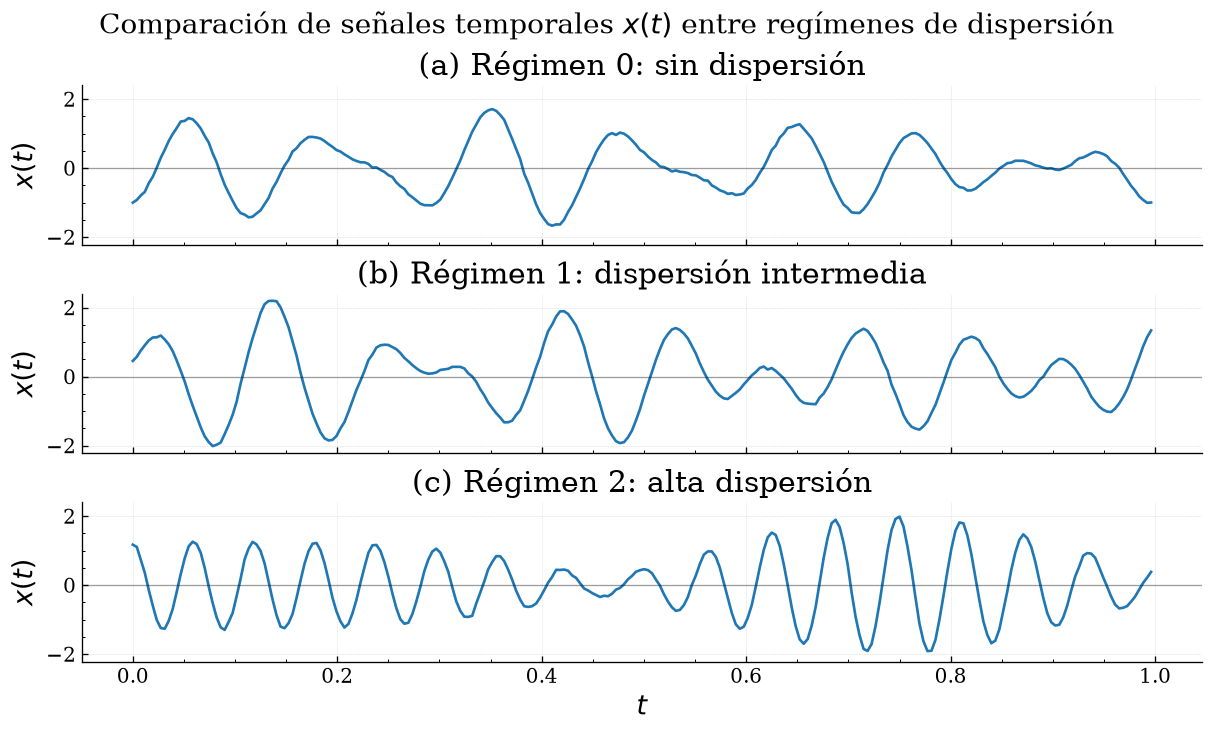

In [6]:
indices = [np.where(y == r)[0][0] for r in range(3)]#buscar la primera señal de cada regimen

titulos = [
    r"(a) Régimen 0: sin dispersión",
    r"(b) Régimen 1: dispersión intermedia",
    r"(c) Régimen 2: alta dispersión",
]

fig, axs = plt.subplots(
    3, 1,
    figsize=(10, 6),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for r, idx in enumerate(indices):
    axs[r].plot(t, X[idx], linewidth=1.6)
    axs[r].axhline(0, color="black", linewidth=0.8, alpha=0.35)
    axs[r].set_title(titulos[r])
    axs[r].set_ylabel(r"$x(t)$")
    axs[r].grid(True)

axs[-1].set_xlabel(r"$t$")

fig.suptitle(
    r"Comparación de señales temporales $x(t)$ entre regímenes de dispersión"
)

plt.show()

**Figura 1.** Señales temporales representativas $x(t)$ para los tres regímenes de dispersión. Se seleccionó una señal de cada etiqueta $y\in\{0,1,2\}$. La figura permite comparar cualitativamente la estructura temporal de las señales antes del entrenamiento de la red neuronal.

## 1. Capa Fourier

En esta sección se construye la capa Fourier que se utilizará para inicializar la primera capa de la red neuronal. Esta capa está formada por filas de senos y cosenos, tal como se pide en la rúbrica.

La matriz se denota por

$$
W_1 \in \mathbb{R}^{2K \times N},
$$

donde $N$ es el número de muestras temporales de cada señal. En este caso,

$$
N = 256.
$$

Se toma $K=20$, por lo que la capa Fourier tiene $2K=40$ filas.

Para cada frecuencia $k=1,\dots,K$, se incorporan las funciones

$$
\sin(2\pi k t)
$$

y

$$
\cos(2\pi k t).
$$

En la implementación, estas funciones se evalúan sobre los puntos temporales de cada señal para formar las filas de $W_1$.


### 1.1 Construcción de la capa Fourier

Como $K=20$ y $N=256$, la construcción de la capa Fourier produce una matriz

$$
W_1\in\mathbb{R}^{2K\times N}
=
\mathbb{R}^{40\times256}
$$

dada por

$$
W_1 =
\begin{bmatrix}
\sin(2\pi\cdot1\cdot \tau_0) & \cdots & \sin(2\pi\cdot1\cdot \tau_{255})\\
\vdots & \ddots & \vdots\\
\sin(2\pi\cdot20\cdot \tau_0) & \cdots & \sin(2\pi\cdot20\cdot \tau_{255})\\
\cos(2\pi\cdot1\cdot \tau_0) & \cdots & \cos(2\pi\cdot1\cdot \tau_{255})\\
\vdots & \ddots & \vdots\\
\cos(2\pi\cdot20\cdot \tau_0) & \cdots & \cos(2\pi\cdot20\cdot \tau_{255})
\end{bmatrix}.
$$

Aquí $\tau_j=j/N$ corresponde al tiempo normalizado en el que se evalúan las funciones seno y coseno para construir las filas de la capa Fourier.

In [7]:
K = 20
N = X.shape[1]

tau = jnp.arange(N) / N
k = jnp.arange(1, K + 1)

W1_sin = jnp.sin(2 * jnp.pi * k[:, None] * tau[None, :])
W1_cos = jnp.cos(2 * jnp.pi * k[:, None] * tau[None, :])

W1 = jnp.vstack([W1_sin, W1_cos])

print("W1.shape =", W1.shape)
print("N =", N)

W1.shape = (40, 256)
N = 256


### 1.2 Verificación frente a `np.fft` (Transformada Discreta de Fourier)

Inicialmente se selecciona una señal del conjunto de datos y se calcula la salida de la capa Fourier:

$$
z = W_1x.
$$

Este paso permite verificar las dimensiones de la operación. Como $x\in\mathbb{R}^{256}$ y $W_1\in\mathbb{R}^{40\times256}$, la salida debe cumplir

$$
z\in\mathbb{R}^{40}.
$$

In [13]:
# Seleccionar una señal del conjunto de datos
x = jnp.array(X[0])

# Aplicar la capa Fourier
z = W1 @ x

print("x.shape =", x.shape)
print("z.shape =", z.shape)

x.shape = (256,)
z.shape = (40,)


In [14]:
print("Coeficientes asociados a las funciones seno:")
print(z[:K])

print("\nCoeficientes asociados a las funciones coseno:")
print(z[K:])

Coeficientes asociados a las funciones seno:
[ 4.47720408e-01  3.34008038e-01  1.08840138e-01  8.68191719e-01
  8.13249588e-01 -5.50313830e-01 -4.36632614e+01  5.54417953e+01
  3.17084675e+01  1.12890526e+02 -4.41303711e+01 -1.75283127e+01
 -1.09743843e+01 -7.88773918e+00 -6.14795303e+00 -5.41703176e+00
 -4.60955524e+00 -3.61072922e+00 -2.62812662e+00 -3.18041635e+00]

Coeficientes asociados a las funciones coseno:
[ 7.8463984e-01  8.2724839e-01  1.0779440e+00  1.3935046e+00
  2.2512667e+00  4.7395577e+00  9.8476761e+01  1.3783740e+01
  3.9818048e-02  3.6207123e+00 -3.0463669e+00 -1.3111539e+00
 -1.2671571e+00 -1.2948383e+00 -3.1015587e-01 -6.5350223e-01
 -9.9100471e-01 -8.4934640e-01 -1.0859661e+00 -9.9274158e-02]


Los primeros K valores corresponden a las proyecciones sobre funciones seno, mientras que los últimos K corresponden a las proyecciones sobre funciones coseno. Para verificar que estos coeficientes coinciden con una representación de Fourier, se comparan a continuación con `np.fft.rfft`.




La Transformada Discreta de Fourier entrega coeficientes complejos. Su parte real está asociada a las funciones coseno, mientras que los coeficientes seno de la capa Fourier coinciden con el negativo de la parte imaginaria de `np.fft.rfft`, debido a la convención exponencial usada por NumPy.

In [15]:
# Transformada Discreta de Fourier de la señal seleccionada usando NumPy
X_fft = np.fft.rfft(np.array(x))

# Se toman las primeras K frecuencias no nulas: k = 1, ..., K
fft_k = X_fft[1:K + 1]

# Coeficientes obtenidos por la capa Fourier
# W1 está organizado como [senos, cosenos]
z = np.array(W1 @ x)
z_sin = z[:K]
z_cos = z[K:]

# Comparación con la FFT
print("Coeficientes coseno de W1x:")
print(np.round(z_cos, 3))

print("\nParte real de la FFT:")
print(np.round(np.real(fft_k), 3))

print("\nCoeficientes seno de W1x:")
print(np.round(z_sin, 3))

print("\nNegativo de la parte imaginaria de la FFT:")
print(np.round(-np.imag(fft_k), 3))

Coeficientes coseno de W1x:
[ 7.8500e-01  8.2700e-01  1.0780e+00  1.3940e+00  2.2510e+00  4.7400e+00
  9.8477e+01  1.3784e+01  4.0000e-02  3.6210e+00 -3.0460e+00 -1.3110e+00
 -1.2670e+00 -1.2950e+00 -3.1000e-01 -6.5400e-01 -9.9100e-01 -8.4900e-01
 -1.0860e+00 -9.9000e-02]

Parte real de la FFT:
[ 7.8500e-01  8.2700e-01  1.0780e+00  1.3940e+00  2.2510e+00  4.7400e+00
  9.8477e+01  1.3784e+01  4.0000e-02  3.6210e+00 -3.0470e+00 -1.3110e+00
 -1.2670e+00 -1.2950e+00 -3.1000e-01 -6.5400e-01 -9.9100e-01 -8.4900e-01
 -1.0860e+00 -9.9000e-02]

Coeficientes seno de W1x:
[ 4.48000e-01  3.34000e-01  1.09000e-01  8.68000e-01  8.13000e-01
 -5.50000e-01 -4.36630e+01  5.54420e+01  3.17080e+01  1.12891e+02
 -4.41300e+01 -1.75280e+01 -1.09740e+01 -7.88800e+00 -6.14800e+00
 -5.41700e+00 -4.61000e+00 -3.61100e+00 -2.62800e+00 -3.18000e+00]

Negativo de la parte imaginaria de la FFT:
[ 4.4800e-01  3.3400e-01  1.0900e-01  8.6800e-01  8.1300e-01 -5.5000e-01
 -4.3663e+01  5.5442e+01  3.1708e+01  1.1289e+02 -

Los resultados muestran que los coeficientes asociados a las funciones coseno coinciden con la parte real de la Transformada Discreta de Fourier. Por otro lado, los coeficientes asociados a las funciones seno coinciden con el negativo de la parte imaginaria.

Esta diferencia de signo se debe a la convención utilizada en la definición compleja de la transformada, donde aparece el término $e^{-2\pi i k\tau}$. En consecuencia, la comparación confirma que la salida de la capa Fourier reproduce correctamente los coeficientes trigonométricos asociados a las primeras $K$ frecuencias no nulas de la Transformada Discreta de Fourier.

### 1.3 Energía media del dataset

La energía media del conjunto de datos se calcula como

$$
\frac{1}{24\cdot256}\sum_{i=1}^{24}\sum_{j=1}^{256} X_{ij}^{2}.
$$

Este valor resume la magnitud cuadrática promedio de las señales y permite caracterizar globalmente la escala de amplitud del conjunto de datos.

In [16]:
energia_media = (X**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.696
